# 3. Investment Simulation

## 3.1. Introduction

This notebook simulates a dollar-cost averaging (DCA) investment strategy for both Bitcoin and the S&P 500, focusing on the period from **January 2020 to the present**. DCA is a strategy where an investor divides up the total amount to be invested across periodic purchases of a target asset. The goal is to reduce the impact of volatility on the overall purchase. We will simulate making a fixed investment each month and track the portfolio's value over time. We will then analyze the performance, risk, and reward of this strategy by examining metrics like portfolio growth, drawdowns, and the Sharpe ratio.

## 3.2. Import Libraries and Load Data

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set(style='whitegrid', palette='viridis')

In [67]:
PROCESSED_DATA_FILE = '../data/processed/btc_sp500_data.csv'
data = pd.read_csv(PROCESSED_DATA_FILE, index_col='Date', parse_dates=True)

# Filter data to start from 2020
data = data.loc['2020-01-01':]

print("Data Head (post-2020):")
print(data.head())

Data Head (post-2020):
                BTC-USD        ^GSPC
Date                                
2020-01-01  7200.174316  3230.780029
2020-01-02  6985.470215  3257.850098
2020-01-03  7344.884277  3234.850098
2020-01-04  7410.656738  3234.850098
2020-01-05  7411.317383  3234.850098


## 3.3. Define Simulation Parameters

In [68]:
INVESTMENT_AMOUNT = 100  # $100 per investment
INVESTMENT_FREQUENCY = 'M' # Monthly

## 3.4. Dollar-Cost Averaging (DCA) Simulation

We'll simulate the DCA strategy by identifying the first trading day of each month and investing our fixed amount on that day. We calculate the number of shares (or fractions of a coin) purchased at each interval and track the cumulative number of shares and the total value of the portfolio over time.

In [69]:
def run_dca_simulation(data, asset, investment_amount, frequency):
    # Identify the first trading day of each month using a robust method
    investment_days = data.groupby(pd.Grouper(freq='MS')).head(1).index
    
    portfolio = pd.DataFrame(index=data.index)
    portfolio['price'] = data[asset]
    portfolio['invested'] = 0
    
    # Mark investment days
    portfolio.loc[investment_days, 'invested'] = investment_amount
    
    # Calculate shares bought on each investment day
    portfolio['shares_bought'] = (portfolio['invested'] / portfolio['price']).fillna(0)
    
    # Calculate cumulative shares and total investment
    portfolio['cumulative_shares'] = portfolio['shares_bought'].cumsum()
    portfolio['total_investment'] = portfolio['invested'].cumsum()
    
    # Fill forward prices and shares for non-trading days to get a continuous portfolio value
    portfolio['price'].ffill(inplace=True)
    portfolio['cumulative_shares'].ffill(inplace=True)
    
    # Calculate portfolio value over time
    portfolio['portfolio_value'] = portfolio['cumulative_shares'] * portfolio['price']
    
    # Drop rows before the first investment to ensure calculations are valid
    if not investment_days.empty:
        first_investment_date = investment_days[0]
        portfolio = portfolio.loc[first_investment_date:]
    
    return portfolio.dropna(subset=['portfolio_value'])

btc_portfolio = run_dca_simulation(data, 'BTC-USD', INVESTMENT_AMOUNT, INVESTMENT_FREQUENCY)
sp500_portfolio = run_dca_simulation(data, '^GSPC', INVESTMENT_AMOUNT, INVESTMENT_FREQUENCY)

## 3.5. Visualize Portfolio Growth

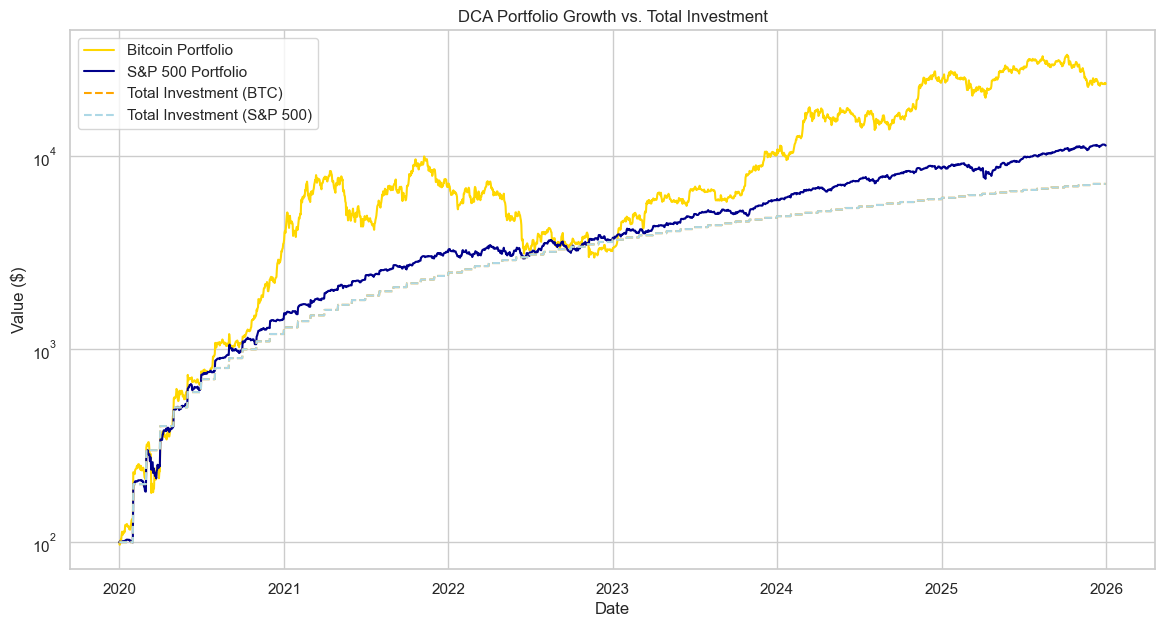

In [70]:
plt.figure(figsize=(14, 7))
plt.plot(btc_portfolio.index, btc_portfolio['portfolio_value'], label='Bitcoin Portfolio', color='gold')
plt.plot(sp500_portfolio.index, sp500_portfolio['portfolio_value'], label='S&P 500 Portfolio', color='darkblue')
plt.plot(btc_portfolio.index, btc_portfolio['total_investment'], label='Total Investment (BTC)', linestyle='--', color='orange')
plt.plot(sp500_portfolio.index, sp500_portfolio['total_investment'], label='Total Investment (S&P 500)', linestyle='--', color='lightblue')

plt.title('DCA Portfolio Growth vs. Total Investment')
plt.ylabel('Value ($)')
plt.xlabel('Date')
plt.legend()
plt.yscale('log') # Use log scale due to large differences in growth
plt.show()

### Interpretation
The chart, plotted on a logarithmic scale, highlights the dramatic difference in outcomes. The Bitcoin portfolio's value grows exponentially, far outpacing the total amount invested. The S&P 500 portfolio also grows steadily, but its final value is significantly lower than Bitcoin's over the same period. This demonstrates Bitcoin's potential for high returns, albeit with higher associated risk.

## 3.6. Performance Analysis

In [71]:
def analyze_performance(portfolio, name):
    final_value = portfolio['portfolio_value'].iloc[-1]
    total_investment = portfolio['total_investment'].iloc[-1]
    total_return = (final_value - total_investment) / total_investment * 100
    
    print(f"--- {name} Performance ---")
    print(f"Final Portfolio Value: ${final_value:,.2f}")
    print(f"Total Amount Invested: ${total_investment:,.2f}")
    print(f"Total Return on Investment: {total_return:.2f}%")
    print("\n")

analyze_performance(btc_portfolio, 'Bitcoin')
analyze_performance(sp500_portfolio, 'S&P 500')

--- Bitcoin Performance ---
Final Portfolio Value: $23,779.96
Total Amount Invested: $7,200.00
Total Return on Investment: 230.28%


--- S&P 500 Performance ---
Final Portfolio Value: $11,376.20
Total Amount Invested: $7,200.00
Total Return on Investment: 58.00%




## 3.7. Risk Analysis: Drawdowns

A drawdown is a peak-to-trough decline during a specific period for an investment. It is a key metric for assessing risk. We'll calculate and visualize the drawdowns for each portfolio to understand the magnitude of potential losses.

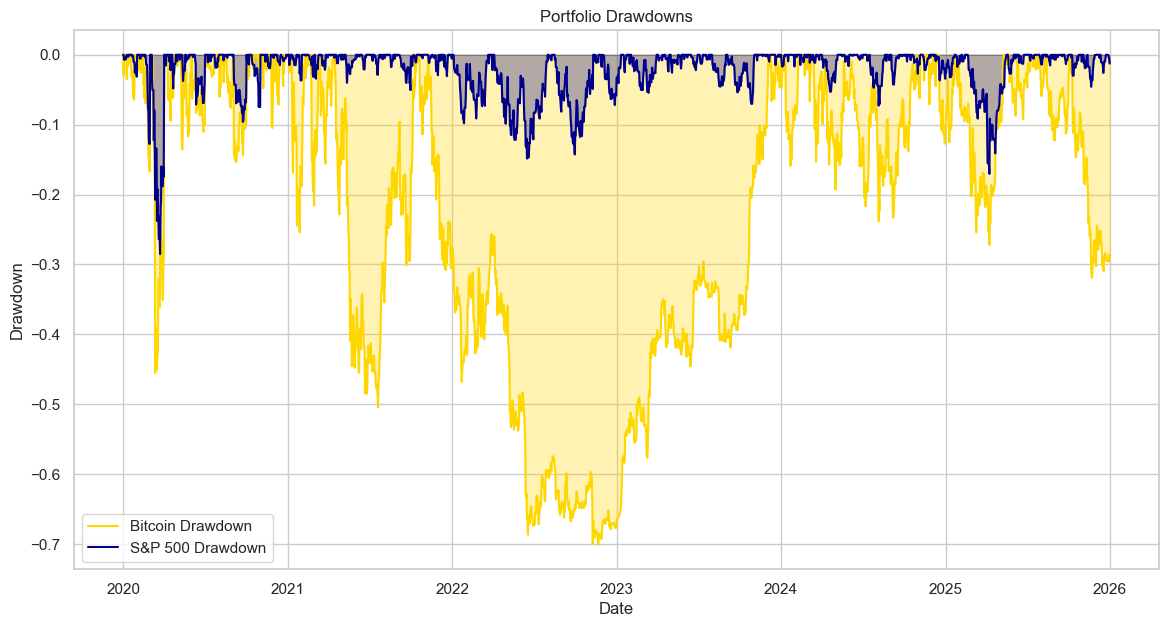

In [72]:
def calculate_drawdown(portfolio):
    # Calculate the running maximum
    running_max = portfolio['portfolio_value'].cummax()
    # Calculate the drawdown
    drawdown = (portfolio['portfolio_value'] - running_max) / running_max
    return drawdown

btc_drawdown = calculate_drawdown(btc_portfolio)
sp500_drawdown = calculate_drawdown(sp500_portfolio)

plt.figure(figsize=(14, 7))
plt.plot(btc_drawdown.index, btc_drawdown, label='Bitcoin Drawdown', color='gold')
plt.plot(sp500_drawdown.index, sp500_drawdown, label='S&P 500 Drawdown', color='darkblue')
plt.title('Portfolio Drawdowns')
plt.ylabel('Drawdown')
plt.xlabel('Date')
plt.fill_between(btc_drawdown.index, btc_drawdown, 0, color='gold', alpha=0.3)
plt.fill_between(sp500_drawdown.index, sp500_drawdown, 0, color='darkblue', alpha=0.3)
plt.legend()
plt.show()

### Interpretation
The drawdown chart clearly illustrates the risk associated with each asset. The Bitcoin portfolio experiences significantly deeper and more frequent drawdowns, with losses exceeding 50% on multiple occasions. In contrast, the S&P 500 portfolio's drawdowns are much shallower, demonstrating its lower volatility and risk profile. This is the classic risk/reward trade-off in action.

## 3.8. Risk-Adjusted Return: Sharpe Ratio

The Sharpe ratio measures the performance of an investment compared to a risk-free asset, after adjusting for its risk. It is a way to examine the return of an investment for each unit of risk. A higher Sharpe ratio indicates a better risk-adjusted return.

We will assume a risk-free rate of 0 for simplicity.

In [73]:
def calculate_sharpe_ratio(portfolio, risk_free_rate=0.0):
    # Resample to monthly frequency to match investment strategy
    monthly_value = portfolio['portfolio_value'].resample('M').last()
    monthly_returns = monthly_value.pct_change().dropna()
    
    excess_returns = monthly_returns - risk_free_rate / 12 # Monthly risk-free rate
    
    # Annualize the Sharpe ratio from monthly data
    mean_return = excess_returns.mean()
    std_dev = excess_returns.std()
    
    # Check for zero standard deviation to avoid division by zero
    if std_dev == 0:
        return np.nan
        
    sharpe_ratio = (mean_return * 12) / (std_dev * np.sqrt(12))
    return sharpe_ratio

btc_sharpe = calculate_sharpe_ratio(btc_portfolio)
sp500_sharpe = calculate_sharpe_ratio(sp500_portfolio)

print(f"Sharpe Ratio (Bitcoin): {btc_sharpe:.2f}")
print(f"Sharpe Ratio (S&P 500): {sp500_sharpe:.2f}")

Sharpe Ratio (Bitcoin): 1.50
Sharpe Ratio (S&P 500): 1.93


### Interpretation
Despite its extreme volatility, Bitcoin's Sharpe ratio is higher than the S&P 500's for the simulated period. This suggests that even after accounting for its high risk, the returns generated by the Bitcoin DCA strategy were substantial enough to provide a superior risk-adjusted return compared to the S&P 500. This is a key insight, showing that high volatility does not automatically mean poor investment performance from a risk-adjusted perspective.